# Google Speech Commands

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
warnings.filterwarnings('ignore')

import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

from torchvision import models
import torchaudio

from sklearn.neighbors import KernelDensity

from tqdm import tqdm

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

from utils import vectorize_tensor, reconstruct_tensor
import ld

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Setup

### General

In [2]:
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    cp.random.seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

load = True

set_random_seed(2)
k = 3
bandwidth = 0.05
bandwidth_AE = 0.05
eps = np.asarray(1.0e-5)

### Dataset

In [3]:
class NumpyDataset(Dataset):
    def __init__(self, features, labels, transform=None):
        # Ensure features are in the correct shape [N, 1, 4000]
        if len(features.shape) == 1:
            features = features.reshape(1, 1, -1)
        elif len(features.shape) == 2:
            features = features.reshape(features.shape[0], 1, -1)

        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sample = self.features[idx].float()
        label = self.labels[idx]

        if self.transform:
            sample = self.transform(sample)

        return sample, label

class Normalize:
    def __init__(self, mean, std):
        # Reshape mean and std to match input dimensions if necessary
        if not torch.is_tensor(mean):
            mean = torch.tensor(mean)
        if not torch.is_tensor(std):
            std = torch.tensor(std)

        # Add channel dimension if needed
        if len(mean.shape) == 1:
            mean = mean.reshape(1, -1)
        if len(std.shape) == 1:
            std = std.reshape(1, -1)

        self.mean = mean
        self.std = std

    def __call__(self, sample):
        # Ensure broadcasting works correctly
        return (sample - self.mean) / (self.std + eps)

# Your transform classes might need modification too
class AddGaussianNoise:
    def __init__(self, mean=0.0, std=0.1):
        self.mean = mean
        self.std = std

    def __call__(self, sample):
        # Ensure noise has the same shape as input
        noise = torch.randn_like(sample) * self.std + self.mean
        return sample + noise

# Composite transformation to combine Normalize and AddGaussianNoise
class CompositeTransform:
    def __init__(self, transforms):
        """
        Args:
            transforms (list): List of transformations to apply in sequence.
        """
        self.transforms = transforms

    def __call__(self, sample):
        for transform in self.transforms:
            sample = transform(sample)
        return sample

In [4]:
D = 4000
S = (2, 5, 2, 5, 2, 5, 2, 2)
train_size_per_class = 1000
new_sample_size_per_class = 200
num_class = 35

# Print dataset statistics
print(f"Train size: {train_size_per_class * num_class}")
print(f"New sample size: {new_sample_size_per_class * num_class}")
print(f"Number of classes: {num_class}")
print(f"Number of features: {D}")

Train size: 35000
New sample size: 7000
Number of classes: 35
Number of features: 4000


In [8]:
# Step 1: Load the dataset
train_dataset = torchaudio.datasets.SPEECHCOMMANDS(root='./data', download=True, subset='training')

def pad_or_truncate(waveform, target_length):
    """
    Pads or truncates the waveform to the target length.
    """
    waveform_length = waveform.shape[-1]
    if waveform_length > target_length:
        # Truncate
        return waveform[:, :target_length]
    elif waveform_length < target_length:
        # Pad with zeros
        padding = target_length - waveform_length
        return torch.nn.functional.pad(waveform, (0, padding))
    return waveform

# Step 2: Create directories and save audio files by class
save_dir = './data/SPEECH_audio'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

    # Get unique labels
    all_labels = sorted(list(set(item[2] for item in train_dataset)))
    label_to_idx = {label: idx for idx, label in enumerate(all_labels)}

    # Save audio files by class
    for idx, (waveform, sample_rate, label, *_) in enumerate(train_dataset):
        class_label = label_to_idx[label]
        class_dir = os.path.join(save_dir, str(class_label))

        if not os.path.exists(class_dir):
            os.makedirs(class_dir)

        # Normalize to 1x16000
        waveform = pad_or_truncate(waveform, target_length=16000)
        waveform_np = waveform.numpy()

        # Sub-sampling to 1x4000
        waveform_np = waveform_np[:, ::4]
        np.save(os.path.join(class_dir, f'{idx}.npy'), waveform_np)

RuntimeError: Couldn't find appropriate backend to handle uri ./data/SpeechCommands/speech_commands_v0.02/backward/0165e0e8_nohash_0.wav and format None.

In [ ]:
# Step 3: Function to load audio files from a directory
def load_audio_from_folder(folder, max_files=20):
    audio_files = []
    for filename in sorted(os.listdir(folder))[:max_files]:
        if filename.endswith('.npy'):
            audio = np.load(os.path.join(folder, filename))
            if audio is not None:
                audio_files.append(audio)

    # print(len(audio_files))
    return audio_files

# Step 4: Load audio and preprocess them
P_class = []

for class_ in range(num_class):
    class_folder = os.path.join(save_dir, str(class_))
    audio_files = load_audio_from_folder(class_folder, max_files=train_size_per_class)

    P = []
    for audio in audio_files:
        # Reshape audio to match your requirements
        array_obj = audio.reshape(S)  # or any other shape you need
        P.append(array_obj)
    P_class.append(np.array(P))

# Normalize to [0, 1]
P_class = np.array(P_class)
P_class = (P_class-P_class.min()) / (P_class.max()-P_class.min())

## Pseudo-Non-Linear Data Augmentation

### Legendre Decomposition (Many-Body Approximation)

In [ ]:
B_LD = ld.default_B(S, 2, cp.get_array_module(P[0]))
# B_LD = ld.default_B(S, 2)
print(f"Dimension of Base Sub-Manifold: {B_LD.shape[0]}")

# Store all intermediate results to disk
if load:
    # Load all intermediate results from disk
    results = np.load('results_LD.npz')
    scaleX_class = results['scaleX_class']
    Q_class = results['Q_class']
    theta_class = results['theta_class']
    X_recons_class = results['X_recons_class']
else:
    import tempfile
    temp_dir = tempfile.mkdtemp(dir='/data/pbb/tmp')

    def LD_helper(i, class_):
        _, _, scaleX, Q, theta = ld.LD(P_class[class_][i], B=B_LD, verbose=False, n_iter=1000, lr=1e-1)
        return (scaleX, Q, theta)


    results = Parallel(n_jobs=30, temp_folder=temp_dir)(delayed(LD_helper)(i, class_) for i in range(train_size_per_class) for class_ in range(num_class))

    scaleX_class = []
    Q_class = []
    theta_class = []
    X_recons_class = []

    for class_ in range(num_class):
        scaleX_list = []
        Q_list = []
        theta_list = []
        X_recons_list = []
        for i in range(train_size_per_class):
            result = results[i*num_class + class_]

            scaleX_list.append(result[0])
            Q_list.append(result[1])
            theta_list.append(result[2])
            X_recons = (result[1] * result[0]).astype(np.int32)
            X_recons_list.append(X_recons)

        scaleX_class.append(np.array(scaleX_list))
        Q_class.append(np.array(Q_list))
        theta_class.append(np.array(theta_list))
        X_recons_class.append(np.array(X_recons_list))

    np.savez('results_LD.npz', scaleX_class=scaleX_class, Q_class=Q_class, theta_class=theta_class, X_recons_class=X_recons_class)

Dimension of Base Sub-Manifold: 136


#### Fitting on Projected Points

In [ ]:
sampled_theta_class = []

for class_ in range(num_class):
    reduced_theta = vectorize_tensor(np.array(theta_class[class_]), B_LD)

    # Fit a KDE to the theta values
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(reduced_theta)
    # Sample new data from the KDE
    sampled_reduced_theta = kde.sample(n_samples=new_sample_size_per_class)

    sampled_theta = reconstruct_tensor(sampled_reduced_theta, (new_sample_size_per_class, *S), B_LD)

    sampled_theta_class.append(sampled_theta)

#### Construct Local-Data Sub-Manifold

In [ ]:
# Construct the constrained coordinates
# B_BP = ld.block_B([14, 14], [15, 15])
B_BP = ld.default_B(S, 3, cp.get_array_module(P[0]))
# B_BP = ld.default_B(S, 3)
print(f"Dimension of Local Data Sub-Manifold: {D - B_BP.shape[0]}")

# Compute every datapoint's eta_hat (served as the linear constraints)
eta_hat_class = []

for class_ in range(num_class):
    eta_hat_list = []
    for i in range(P_class[class_].shape[0]):
        xp = cp.get_array_module(P_class[class_][i])
        # xp = np
        P = (P_class[class_][i] + eps) / scaleX_class[class_][i]
        eta_hat = ld.get_eta(P, len(S), xp)
        eta_hat_list.append(eta_hat)

    eta_hat_class.append(cp.asarray(eta_hat_list))
    # eta_hat_class.append(np.asarray(eta_hat_list))

Dimension of Local Data Sub-Manifold: 3430


#### Backward Projection

In [ ]:
if load:
    # Load all intermediate results from disk
    results_BP = np.load('results_BP.npz')
    sampled_P_BP_class = results_BP['sampled_P_BP_class']
    sampled_theta_BP_class = results_BP['sampled_theta_BP_class']
    sampled_X_BP_class = results_BP['sampled_X_BP_class']
else:
    # Use a custom temporary directory
    import tempfile
    temp_dir = tempfile.mkdtemp(dir='/data/pbb/tmp')


    def BP_helper(i, class_):
        N = ld.kNN(sampled_theta_class[class_][i], theta_class[class_], k=k)
        avg_scale = np.mean(scaleX_class[class_][N])
        avg_eta_hat = np.mean(eta_hat_class[class_][N], axis=0)
        _, _, P, theta = ld.BP(sampled_theta_class[class_][i], [(P_class[class_][j] + eps) / scaleX_class[class_][j] for j in N], avg_eta_hat, avg_scale, B=B_BP, verbose=False, n_iter=1000, lr=1e-1)
        X_recons_ = (P).astype(np.int32).reshape(-1)
        return (P, theta, X_recons_)

    results = Parallel(n_jobs=10, temp_folder=temp_dir)(delayed(BP_helper)(i, class_) for i in range(new_sample_size_per_class) for class_ in range(num_class))

    sampled_P_BP_class = []
    sampled_theta_BP_class = []
    sampled_X_BP_class = []

    for class_ in range(num_class):
        sampled_P_BP = []
        sampled_theta_BP = []
        sampled_X_BP = []
        for i in range(new_sample_size_per_class):
            result = results[i*num_class + class_]

            sampled_P_BP.append(result[0])
            sampled_theta_BP.append(result[1])
            sampled_X_BP.append(result[2])

        sampled_P_BP_class.append(np.array(sampled_P_BP))
        sampled_theta_BP_class.append(np.array(sampled_theta_BP))
        sampled_X_BP_class.append(np.array(sampled_X_BP))

    np.savez('results_BP.npz', sampled_P_BP_class=sampled_P_BP_class, sampled_theta_BP_class=sampled_theta_BP_class, sampled_X_BP_class=sampled_X_BP_class)

## Data Augmentation with Autoencoder

In [ ]:
class SpeechCommandsDataset(Dataset):
    def __init__(self, subset='training', transform=None):
        """
        Args:
            subset (str): 'training' or 'testing'
            transform (callable, optional): Optional transform to be applied
        """
        super().__init__()
        self.dataset = torchaudio.datasets.SPEECHCOMMANDS(
            root='./data',
            download=True,
            subset=subset
        )
        self.transform = transform

        # Get unique labels and create label mapping
        all_labels = sorted(list(set(item[2] for item in self.dataset)))
        self.label_to_idx = {label: idx for idx, label in enumerate(all_labels)}

        # Precompute all waveforms with subsampling
        print(f"Precomputing features for {subset} set...")
        self.precomputed_waveforms = []
        self.labels = []

        for waveform, _, label, *_ in tqdm(self.dataset):
            # Pad/truncate to 16000 first
            if waveform.shape[-1] > 16000:
                waveform = waveform[:, :16000]
            elif waveform.shape[-1] < 16000:
                padding = 16000 - waveform.shape[-1]
                waveform = torch.nn.functional.pad(waveform, (0, padding))

            # Subsample by taking every 4th sample
            waveform = waveform[:, ::4]  # Now length is 4000

            self.precomputed_waveforms.append(waveform)
            self.labels.append(self.label_to_idx[label])

        # Convert to tensors
        self.precomputed_waveforms = torch.stack(self.precomputed_waveforms)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

        print(f"Precomputed {len(self.precomputed_waveforms)} waveforms")
        print(f"Waveform shape: {self.precomputed_waveforms[0].shape}")  # Should be [1, 4000]

    def __len__(self):
        return len(self.precomputed_waveforms)

    def __getitem__(self, idx):
        waveform = self.precomputed_waveforms[idx]
        label = self.labels[idx]

        if self.transform:
            waveform = self.transform(waveform)

        return waveform, label

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_size=D, hidden_size=B_LD.shape[0], z_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, z_dim)
        self.relu = nn.ReLU()
    def forward(self , x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class Decoder(nn.Module):
    def __init__(self, output_size=D, hidden_size=B_LD.shape[0], z_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(z_dim , hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    def forward(self , x):
        x = self.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

Precomputing features for training set...


100%|██████████| 84843/84843 [04:00<00:00, 352.36it/s]


Precomputed 84843 waveforms
Waveform shape: torch.Size([1, 4000])


100%|██████████| 100/100 [10:00<00:00,  6.00s/it]


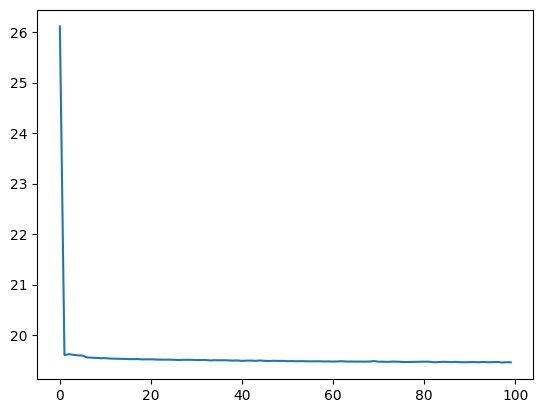

In [ ]:
train_loader_original = DataLoader(SpeechCommandsDataset(subset='training'), batch_size=32, shuffle=True)

enc = Encoder().to(device)
dec = Decoder().to(device)
loss_fn = nn.MSELoss()
optimizer_enc = torch.optim.Adam(enc.parameters(), lr=1e-3)
optimizer_dec = torch.optim.Adam(dec.parameters(), lr=1e-3)

train_loss = []
num_epochs = 100

for epoch in tqdm(range(num_epochs)):
    train_epoch_loss = 0
    for (x , _) in train_loader_original:
        x = x.to(device)
        x = x.flatten(1)
        latents = enc(x)
        output = dec(latents)
        loss = loss_fn(output , x)
        train_epoch_loss += loss.cpu().detach().numpy()
        optimizer_enc.zero_grad()
        optimizer_dec.zero_grad()
        loss.backward()
        optimizer_enc.step()
        optimizer_dec.step()
    train_loss.append(train_epoch_loss)
plt.plot(train_loss)

In [ ]:
representation = None
all_labels = []

with torch.no_grad():
    for (xs , labels) in train_loader_original:
        xs = xs.to(device)
        xs = xs.flatten(1)
        all_labels.extend(list(labels.numpy()))
        latents = enc(xs)
        if representation is None:
            representation = latents.cpu()
        else:
            representation = torch.vstack([representation , latents.cpu()])

all_labels = np.array(all_labels)
representation = representation.numpy()

In [ ]:
sampled_X_AE_class = []

for class_ in range(num_class):
    sampled_X_AE_list = []

    rep = representation[np.argwhere(all_labels == class_)].squeeze()
    # Fit a KDE to the theta values
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth_AE).fit(rep)

    # Sample new data from the KDE
    sampled_rep = kde.sample(n_samples=new_sample_size_per_class)
    for i in range(new_sample_size_per_class):
        pred = dec(torch.Tensor(sampled_rep[i])[None , ...].to(device)).cpu().detach().numpy()
        sampled_X_AE_list.append(pred.flatten())

    sampled_X_AE_class.append(sampled_X_AE_list)

## Classification Performance

### Dataset Preparation

In [ ]:
# Helper function to create a DataLoader for augmented datasets
def prepare_augmented_dataset(original_dataset, augmented_data, augmented_labels, transform, batch_size, augmented_ratio=1.0):
    # Ensure augmented data has the correct shape [N, 1, 4000]
    if len(augmented_data.shape) == 1:
        augmented_data = augmented_data.reshape(1, 1, -1)
    elif len(augmented_data.shape) == 2:
        augmented_data = augmented_data.reshape(augmented_data.shape[0], 1, -1)

    # Reduce the size of augmented data according to the augmented_ratio
    total_augmented = len(augmented_data)
    num_selected = int(total_augmented * augmented_ratio)

    if num_selected < total_augmented:  # Sample only if reducing
        indices = np.random.choice(total_augmented, num_selected, replace=False)
        augmented_data = augmented_data[indices]
        augmented_labels = augmented_labels[indices]

    # Create dataset from augmented data
    augmented_dataset = NumpyDataset(features=augmented_data, labels=augmented_labels, transform=transform)

    # Combine with the original dataset
    combined_dataset = ConcatDataset([original_dataset, augmented_dataset])

    # Create a DataLoader for the combined dataset
    return DataLoader(dataset=combined_dataset, batch_size=batch_size, shuffle=True)

# Main function to prepare datasets and loaders
def create_datasets_and_loaders(batch_size=64, augmented_ratio=1.0):
    # Define transformations
    train_dataset = SpeechCommandsDataset(subset='training')
    test_dataset = SpeechCommandsDataset(subset='testing')

    # Calculate normalization statistics from training data
    mean = torch.mean(train_dataset.precomputed_waveforms)
    std = torch.std(train_dataset.precomputed_waveforms)

    transform_standard = CompositeTransform([
        Normalize(mean, std),
        AddGaussianNoise(mean=0.0, std=std.min()/4)  # Add Gaussian noise with 1/4 of the standard deviation
    ])
    transform_none = Normalize(mean, std)

    train_standard = train_dataset
    train_standard.transform = transform_standard
    train_none = train_dataset
    train_none.transform = transform_none

    test_dataset.transform = transform_none

    augmented_data_PNL, labels_PNL = [], []
    augmented_data_AE, labels_AE = [], []

    for class_ in range(num_class):
        for data_PNL in sampled_X_BP_class[class_]:
            augmented_data_PNL.append(data_PNL)
            labels_PNL.append(class_)

        for data_AE in sampled_X_AE_class[class_]:
            augmented_data_AE.append(data_AE)
            labels_AE.append(class_)

    augmented_data_PNL = np.array(augmented_data_PNL)
    labels_PNL = np.array(labels_PNL)
    augmented_data_AE = np.array(augmented_data_AE)
    labels_AE = np.array(labels_AE)

    mean_LD = augmented_data_PNL.mean(axis=0)
    std_LD = augmented_data_PNL.std(axis=0)
    transform_none_LD = Normalize(mean_LD, std_LD)

    mean_AE = augmented_data_AE.mean(axis=0)
    std_AE = augmented_data_AE.std(axis=0)
    transform_none_AE = Normalize(mean_AE, std_AE)

    # Combine Speech Commands dataset with a subset of augmented data
    train_loader_PNL = prepare_augmented_dataset(train_none, augmented_data_PNL, labels_PNL, transform_none_LD, batch_size, augmented_ratio)
    train_loader_AE = prepare_augmented_dataset(train_none, augmented_data_AE, labels_AE, transform_none_AE, batch_size, augmented_ratio)

    # DataLoader for Speech Commands only
    train_loader_standard = DataLoader(train_standard, batch_size=batch_size, shuffle=True)
    train_loader_none = DataLoader(train_none, batch_size=batch_size, shuffle=True)

    return {
        "standard": train_loader_standard,
        "none": train_loader_none,
        "PNL_augmented": train_loader_PNL,
        "AE_augmented": train_loader_AE,
    }, test_dataset

# Create dictionaries of loaders for different datasets
train_loader_standard = {}
train_loader_none = {}
train_loader_PNL = {}
train_loader_AE = {}

# Example Usage: Testing different dataset sizes
for ratio in [0.0, 0.25, 0.5, 0.75, 1.0]:  # Testing different proportions of augmented data
    print(f"Testing with augmented_ratio = {ratio}")
    loaders, test_dataset = create_datasets_and_loaders(batch_size=64, augmented_ratio=ratio)

    for name, loader in loaders.items():
        print(f"{name} loader:")
        for data, labels in loader:
            print(f"data shape: {data.shape}, Labels shape: {labels.shape}")
            break

    train_loader_standard[ratio] = loaders["standard"]
    train_loader_none[ratio] = loaders["none"]
    train_loader_PNL[ratio] = loaders["PNL_augmented"]
    train_loader_AE[ratio] = loaders["AE_augmented"]


Precomputing features for training set...


100%|██████████| 84843/84843 [03:59<00:00, 354.47it/s]


Precomputed 84843 waveforms
Waveform shape: torch.Size([1, 4000])
Precomputing features for testing set...


100%|██████████| 11005/11005 [00:30<00:00, 357.18it/s]


Precomputed 11005 waveforms
Waveform shape: torch.Size([1, 4000])
standard loader:
Images shape: torch.Size([64, 1, 4000]), Labels shape: torch.Size([64])
none loader:
Images shape: torch.Size([64, 1, 4000]), Labels shape: torch.Size([64])
PNL_augmented loader:
Images shape: torch.Size([64, 1, 4000]), Labels shape: torch.Size([64])
AE_augmented loader:
Images shape: torch.Size([64, 1, 4000]), Labels shape: torch.Size([64])


### ResNet18 Model

In [ ]:
import torch.nn.functional as F

class M5(nn.Module):
    """
    M5 model architecture adapted for subsampled audio (4000 samples instead of 16000)
    """
    def __init__(self, n_input=1, n_output=35, stride=4, n_channel=32):
        super().__init__()

        # Adjusted kernel sizes and strides for 4000-sample input
        self.conv1 = nn.Conv1d(n_input, n_channel, kernel_size=20, stride=stride).float()
        self.bn1 = nn.BatchNorm1d(n_channel).float()
        self.pool1 = nn.MaxPool1d(4)

        self.conv2 = nn.Conv1d(n_channel, n_channel, kernel_size=3).float()
        self.bn2 = nn.BatchNorm1d(n_channel).float()
        self.pool2 = nn.MaxPool1d(4)

        self.conv3 = nn.Conv1d(n_channel, 2 * n_channel, kernel_size=3).float()
        self.bn3 = nn.BatchNorm1d(2 * n_channel).float()
        self.pool3 = nn.MaxPool1d(4)

        self.conv4 = nn.Conv1d(2 * n_channel, 2 * n_channel, kernel_size=3).float()
        self.bn4 = nn.BatchNorm1d(2 * n_channel).float()
        self.pool4 = nn.MaxPool1d(4)

        self.fc1 = nn.Linear(2 * n_channel, n_output).float()

    def forward(self, x):
        x = x.float()

        x = self.conv1(x)
        x = F.relu(self.bn1(x))
        x = self.pool1(x)

        x = self.conv2(x)
        x = F.relu(self.bn2(x))
        x = self.pool2(x)

        x = self.conv3(x)
        x = F.relu(self.bn3(x))
        x = self.pool3(x)

        x = self.conv4(x)
        x = F.relu(self.bn4(x))
        x = self.pool4(x)

        x = F.avg_pool1d(x, x.shape[-1])
        x = x.permute(0, 2, 1)
        x = self.fc1(x)

        return F.log_softmax(x, dim=2).squeeze()

def train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs, device='cuda'):
    train_loss = []
    model.to(device)
    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_epoch_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_epoch_loss += loss.item()

        scheduler.step()
        train_loss.append(train_epoch_loss)

    plt.plot(train_loss)

def test_model(model, test_loader, device='cuda'):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

def bootstrapping(train_loader, test_dataset, num_epochs=100, learning_rate=1e-1, n_bootstrap=20, device='cuda'):
    """
    Train the ResNet model on the training dataset, and evaluate it using bootstrapping on the test dataset.

    Args:
        train_loader: DataLoader for training data.
        test_dataset: Dataset object for the test data.
        num_epochs: Number of epochs for training.
        learning_rate: Learning rate for the optimizer.
        device: Device to run the training on ('cuda' or 'cpu').

    Returns:
        Prints the mean accuracy and 95% confidence interval after bootstrapping.
    """
    # Initialize the model, loss, optimizer, and scheduler
    model = M5().to(device)
    model = model.float()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)  # Decay LR every 30 epochs

    # Train the model
    train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=num_epochs, device=device)

    # Perform bootstrapping
    accuracies = []

    num_test_samples = len(test_dataset) // 2
    for i in range(n_bootstrap):
        indices = torch.randint(len(test_dataset), size=(num_test_samples,))  # Sample 500 random indices
        bootstrap_subset = Subset(test_dataset, indices)
        bootstrap_loader = DataLoader(dataset=bootstrap_subset, batch_size=num_test_samples, shuffle=False)

        accuracy = test_model(model, bootstrap_loader, device=device)
        accuracies.append(accuracy)

    # Compute statistics
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"Mean accuracy: {mean_accuracy:.2f}%")
    print(f"Standard deviation: {std_accuracy:.2f}")

### Dataset Performance

In [ ]:
for ratio in [0.0, 0.25, 0.5, 0.75, 1.0]:
    print(f"Testing with augmented_ratio = {ratio}")
    print("Standard:")
    bootstrapping(train_loader_standard[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)
    print("None:")
    bootstrapping(train_loader_none[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)
    print("PNL:")
    bootstrapping(train_loader_PNL[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)
    print("AE:")
    bootstrapping(train_loader_AE[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)

Epoch [1/50], Loss: 1.5258


Epoch [2/50], Loss: 0.9701
Epoch [3/50], Loss: 0.8856
Epoch [4/50], Loss: 0.8579
Epoch [5/50], Loss: 0.8359
Epoch [6/50], Loss: 0.8195
Epoch [7/50], Loss: 0.8117
Epoch [8/50], Loss: 0.8087
Epoch [9/50], Loss: 0.7983
Epoch [10/50], Loss: 0.7910
Epoch [11/50], Loss: 0.7990
Epoch [12/50], Loss: 0.7876
Epoch [13/50], Loss: 0.7903
Epoch [14/50], Loss: 0.7882
Epoch [15/50], Loss: 0.7845
Epoch [16/50], Loss: 0.7889
Epoch [17/50], Loss: 0.7835
Epoch [18/50], Loss: 0.7796
Epoch [19/50], Loss: 0.7752
Epoch [20/50], Loss: 0.7802
Epoch [21/50], Loss: 0.7816
Epoch [22/50], Loss: 0.7698
Epoch [23/50], Loss: 0.7811
Epoch [24/50], Loss: 0.7694
Epoch [25/50], Loss: 0.7754
Epoch [26/50], Loss: 0.7821
Epoch [27/50], Loss: 0.7733
Epoch [28/50], Loss: 0.7758
Epoch [29/50], Loss: 0.7707
Epoch [30/50], Loss: 0.7752
Epoch [31/50], Loss: 0.5287
Epoch [32/50], Loss: 0.4795
Epoch [33/50], Loss: 0.4669
Epoch [34/50], Loss: 0.4605
Epoch [35/50], Loss: 0.4572
Epoch [36/50], Loss: 0.4538
Epoch [37/50], Loss: 0.4552
